## Autoregressive MLP on Toy Data
Generate train/test sets (n=5000 targets each), train an autoregressive MLP, and evaluate with plots + metrics.

In [ ]:
from pathlib import Path
import json

from toy_data.adapters import build_autoregressive_dataset

k = 20
n_examples = 5000

# build_autoregressive_dataset yields n-k samples, so generate n_examples + k flips
raw_train_n = n_examples + k
raw_test_n = n_examples + k

train_seed = 42
test_seed = 314

X_train, y_train, p_true_train = build_autoregressive_dataset(
    n=raw_train_n,
    k=k,
    seed=train_seed,
    include_p_true=True,
)

X_test, y_test, p_true_test = build_autoregressive_dataset(
    n=raw_test_n,
    k=k,
    seed=test_seed,
    include_p_true=True,
)

assert len(X_train) == n_examples
assert len(X_test) == n_examples

print('Train samples:', len(X_train))
print('Test samples:', len(X_test))
print('Feature length (k):', len(X_train[0]))

out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)
with (out_dir / 'mlp_train_n5000.json').open('w', encoding='utf-8') as f:
    json.dump({'X': X_train, 'y': y_train, 'p_true': p_true_train}, f)
with (out_dir / 'mlp_test_n5000.json').open('w', encoding='utf-8') as f:
    json.dump({'X': X_test, 'y': y_test, 'p_true': p_true_test}, f)

print('Saved: toy_data/mlp_train_n5000.json')
print('Saved: toy_data/mlp_test_n5000.json')

Train samples: 5000
Test samples: 5000
Feature length (k): 20
Saved: toy_data/mlp_train_n5000.json
Saved: toy_data/mlp_test_n5000.json


In [2]:
import torch
from torch.utils.data import Dataset, DataLoader


class FlipWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        y_signed = torch.tensor(y, dtype=torch.float32)
        self.y = ((y_signed + 1.0) / 2.0).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 64
train_dataset = FlipWindowDataset(X_train, y_train)
test_dataset = FlipWindowDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print('Train dataset size:', len(train_dataset))
print('Test dataset size:', len(test_dataset))
print('x shape:', tuple(xb.shape), '| y shape:', tuple(yb.shape))

Train dataset size: 5000
Test dataset size: 5000
x shape: (64, 20) | y shape: (64, 1)


In [5]:
import copy
import torch.nn as nn
import torch.optim as optim


class AutoregressiveMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoregressiveMLP(input_dim=k).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 25
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        preds = model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = criterion(preds, yb)
            test_loss += loss.item() * xb.size(0)

            yhat = (preds >= 0.5).float()
            correct += (yhat == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6823 | test_loss=0.6675 | test_acc=0.5960
Epoch 02 | train_loss=0.6679 | test_loss=0.6643 | test_acc=0.6048
Epoch 03 | train_loss=0.6636 | test_loss=0.6646 | test_acc=0.6062
Epoch 04 | train_loss=0.6610 | test_loss=0.6648 | test_acc=0.6066
Epoch 05 | train_loss=0.6584 | test_loss=0.6657 | test_acc=0.6054
Epoch 06 | train_loss=0.6548 | test_loss=0.6666 | test_acc=0.6042
Epoch 07 | train_loss=0.6525 | test_loss=0.6685 | test_acc=0.6006
Epoch 08 | train_loss=0.6488 | test_loss=0.6689 | test_acc=0.6038
Epoch 09 | train_loss=0.6458 | test_loss=0.6714 | test_acc=0.5976
Epoch 10 | train_loss=0.6426 | test_loss=0.6750 | test_acc=0.5982
Epoch 11 | train_loss=0.6400 | test_loss=0.6738 | test_acc=0.5962
Epoch 12 | train_loss=0.6348 | test_loss=0.6762 | test_acc=0.5922
Epoch 13 | train_loss=0.6303 | test_loss=0.6813 | test_acc=0.5824
Epoch 14 | train_loss=0.6272 | test_loss=0.6829 | test_acc=0.5862
Epoch 15 | train_loss=0.6220 | test_loss=0.6871 | test_acc=0.5842
Epoch 16 |

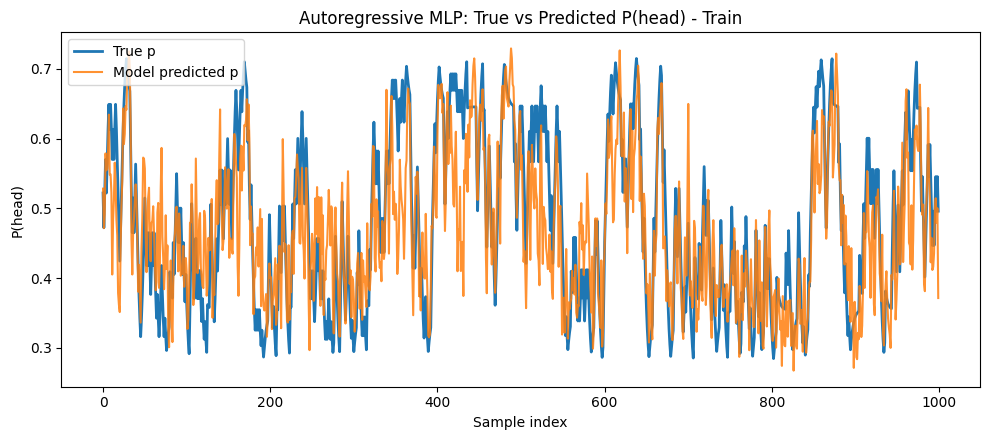

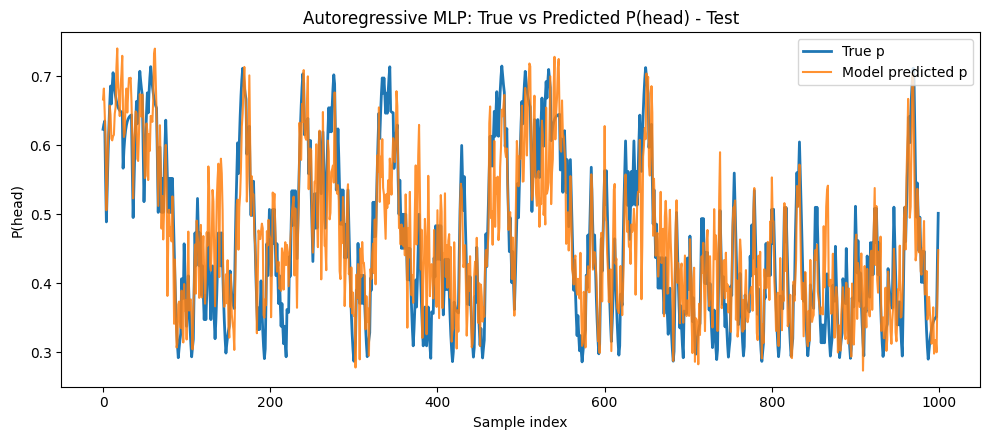

Saved: true_vs_pred_p_mlp_train.png
Saved: true_vs_pred_p_mlp_test.png
Saved: metrics_mlp_comparison.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0529  | 0.0676  | 0.8360 
Test       | 0.0518  | 0.0658  | 0.8493 


In [6]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_from_model,
    plot_true_vs_pred_p_over_samples,
    save_metrics_comparison_table_png,
)

def mlp_predictor(m, sample):
    m.eval()
    with torch.no_grad():
        xt = torch.tensor(sample, dtype=torch.float32, device=device).unsqueeze(0)
        return float(m(xt).item())

p_pred_train = plot_true_vs_pred_p_over_samples(
    model=model,
    X=X_train,
    p_true=p_true_train,
    predictor=mlp_predictor,
    max_points=1000,
    save_path='true_vs_pred_p_mlp_train.png',
    title='Autoregressive MLP: True vs Predicted P(head) - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples(
    model=model,
    X=X_test,
    p_true=p_true_test,
    predictor=mlp_predictor,
    max_points=1000,
    save_path='true_vs_pred_p_mlp_test.png',
    title='Autoregressive MLP: True vs Predicted P(head) - Test',
    show=True,
 )

metrics_train = compute_true_vs_pred_metrics_from_model(
    model=model,
    X=X_train,
    p_true=p_true_train,
    predictor=mlp_predictor,
 )

metrics_test = compute_true_vs_pred_metrics_from_model(
    model=model,
    X=X_test,
    p_true=p_true_test,
    predictor=mlp_predictor,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_mlp_comparison.png',
)

print('Saved: true_vs_pred_p_mlp_train.png')
print('Saved: true_vs_pred_p_mlp_test.png')
print('Saved: metrics_mlp_comparison.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))

In [1]:
from pathlib import Path
import json

from toy_data.adapters import build_autoregressive_dataset

k = 20
n_examples = 5000

# build_autoregressive_dataset yields n-k samples, so generate n_examples + k flips
raw_train_n = n_examples + k
raw_test_n = n_examples + k

train_seed = 42
test_seed = 314

X_train, y_train, p_true_train = build_autoregressive_dataset(
    n=raw_train_n,
    k=k,
    seed=train_seed,
    include_p_true=True,
    mode='probabilistic'
)

X_test, y_test, p_true_test = build_autoregressive_dataset(
    n=raw_test_n,
    k=k,
    seed=test_seed,
    include_p_true=True,
    mode='probabilistic'
)

assert len(X_train) == n_examples
assert len(X_test) == n_examples

print('Train samples:', len(X_train))
print('Test samples:', len(X_test))
print('Feature length (k):', len(X_train[0]))

out_dir = Path('toy_data')
out_dir.mkdir(parents=True, exist_ok=True)
with (out_dir / 'mlp_train_probabilistic_n5000.json').open('w', encoding='utf-8') as f:
    json.dump({'X': X_train, 'y': y_train, 'p_true': p_true_train}, f)
with (out_dir / 'mlp_test_probabilistic_n5000.json').open('w', encoding='utf-8') as f:
    json.dump({'X': X_test, 'y': y_test, 'p_true': p_true_test}, f)

print('Saved: toy_data/mlp_train_probabilistic_n5000.json')
print('Saved: toy_data/mlp_test_probabilistic_n5000.json')

Train samples: 5000
Test samples: 5000
Feature length (k): 20
Saved: toy_data/mlp_train_probabilistic_n5000.json
Saved: toy_data/mlp_test_probabilistic_n5000.json


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader


class FlipWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        y_signed = torch.tensor(y, dtype=torch.float32)
        self.y = ((y_signed + 1.0) / 2.0).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 64
train_dataset = FlipWindowDataset(X_train, y_train)
test_dataset = FlipWindowDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print('Train dataset size:', len(train_dataset))
print('Test dataset size:', len(test_dataset))
print('x shape:', tuple(xb.shape), '| y shape:', tuple(yb.shape))

Train dataset size: 5000
Test dataset size: 5000
x shape: (64, 20) | y shape: (64, 1)


In [4]:
import copy
import torch.nn as nn
import torch.optim as optim


class AutoregressiveMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 64),
            nn.LeakyReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model2 = AutoregressiveMLP(input_dim=k).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model2.parameters(), lr=1e-3)

epochs = 25
best_test_loss = float('inf')
best_epoch = 0
best_state = None

for epoch in range(1, epochs + 1):
    model2.train()
    train_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        preds = model2(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * xb.size(0)

    train_loss /= len(train_loader.dataset)

    model2.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model2(xb)
            loss = criterion(preds, yb)
            test_loss += loss.item() * xb.size(0)

            yhat = (preds >= 0.5).float()
            correct += (yhat == yb).sum().item()
            total += yb.numel()

    test_loss /= len(test_loader.dataset)
    test_acc = correct / total

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model2.state_dict())

    print(
        f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | '
        f'test_loss={test_loss:.4f} | test_acc={test_acc:.4f}'
    )

if best_state is not None:
    model2.load_state_dict(best_state)
print(f'Loaded best checkpoint from epoch {best_epoch} with test_loss={best_test_loss:.4f}')

Epoch 01 | train_loss=0.6827 | test_loss=0.6856 | test_acc=0.5626
Epoch 02 | train_loss=0.6691 | test_loss=0.6847 | test_acc=0.5622
Epoch 03 | train_loss=0.6643 | test_loss=0.6843 | test_acc=0.5714
Epoch 04 | train_loss=0.6620 | test_loss=0.6843 | test_acc=0.5678
Epoch 05 | train_loss=0.6588 | test_loss=0.6873 | test_acc=0.5666
Epoch 06 | train_loss=0.6551 | test_loss=0.6877 | test_acc=0.5648
Epoch 07 | train_loss=0.6516 | test_loss=0.6894 | test_acc=0.5682
Epoch 08 | train_loss=0.6472 | test_loss=0.6925 | test_acc=0.5590
Epoch 09 | train_loss=0.6440 | test_loss=0.6922 | test_acc=0.5610
Epoch 10 | train_loss=0.6401 | test_loss=0.6981 | test_acc=0.5612
Epoch 11 | train_loss=0.6343 | test_loss=0.7008 | test_acc=0.5560
Epoch 12 | train_loss=0.6317 | test_loss=0.7030 | test_acc=0.5536
Epoch 13 | train_loss=0.6262 | test_loss=0.7036 | test_acc=0.5560
Epoch 14 | train_loss=0.6216 | test_loss=0.7096 | test_acc=0.5568
Epoch 15 | train_loss=0.6171 | test_loss=0.7159 | test_acc=0.5492
Epoch 16 |

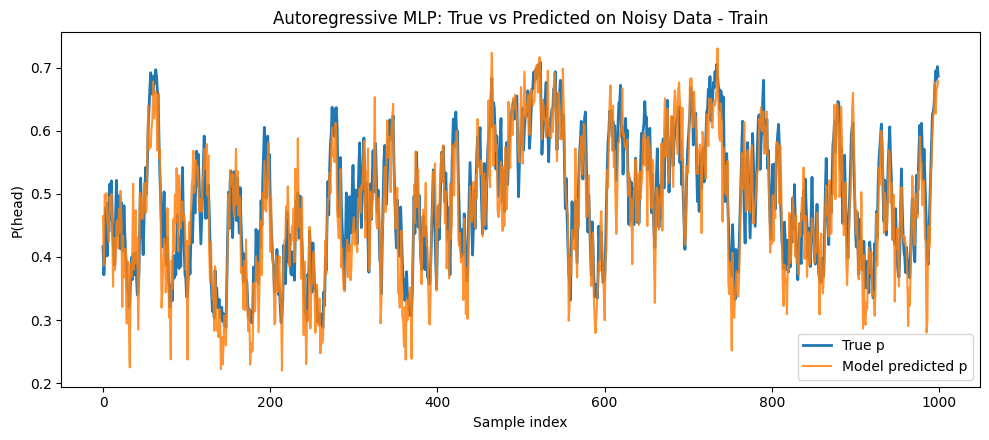

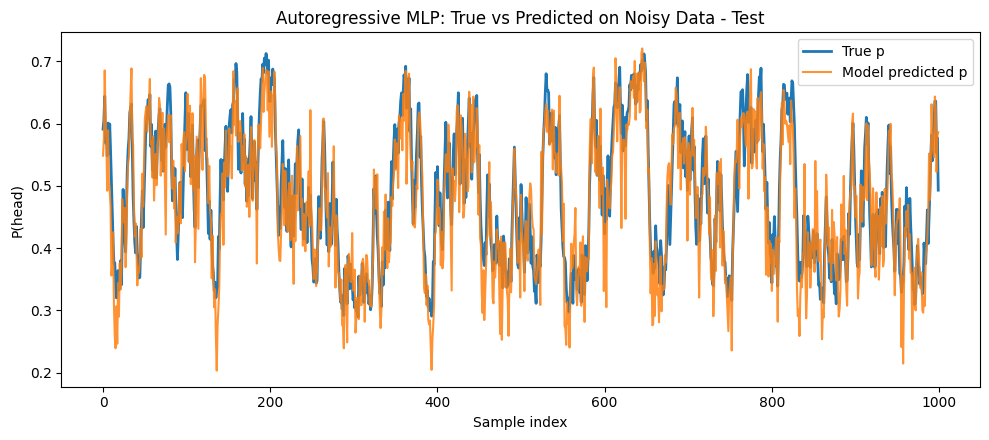

Saved: true_vs_pred_p_mlp_train_noisy.png
Saved: true_vs_pred_p_mlp_test_noisy.png
Saved: metrics_mlp_comparison_noisy.png

           |   MAE   |  RMSE   |  Corr  
-----------|---------|---------|--------
Train      | 0.0405  | 0.0507  | 0.8991 
Test       | 0.0404  | 0.0506  | 0.8911 


In [6]:
import importlib
import toy_data
import toy_data.plotting as toy_plotting

importlib.reload(toy_plotting)
importlib.reload(toy_data)

from toy_data import (
    compute_true_vs_pred_metrics_from_model,
    plot_true_vs_pred_p_over_samples,
    save_metrics_comparison_table_png,
)

def mlp_predictor(m, sample):
    m.eval()
    with torch.no_grad():
        xt = torch.tensor(sample, dtype=torch.float32, device=device).unsqueeze(0)
        return float(m(xt).item())

p_pred_train = plot_true_vs_pred_p_over_samples(
    model=model2,
    X=X_train,
    p_true=p_true_train,
    predictor=mlp_predictor,
    max_points=1000,
    save_path='true_vs_pred_p_mlp_train_noisy.png',
    title='Autoregressive MLP: True vs Predicted on Noisy Data - Train',
    show=True,
 )

p_pred_test = plot_true_vs_pred_p_over_samples(
    model=model2,
    X=X_test,
    p_true=p_true_test,
    predictor=mlp_predictor,
    max_points=1000,
    save_path='true_vs_pred_p_mlp_test_noisy.png',
    title='Autoregressive MLP: True vs Predicted on Noisy Data - Test',
    show=True,
 )

metrics_train = compute_true_vs_pred_metrics_from_model(
    model=model2,
    X=X_train,
    p_true=p_true_train,
    predictor=mlp_predictor,
 )

metrics_test = compute_true_vs_pred_metrics_from_model(
    model=model2,
    X=X_test,
    p_true=p_true_test,
    predictor=mlp_predictor,
 )

save_metrics_comparison_table_png(
    {'Train': metrics_train, 'Test': metrics_test},
    save_path='metrics_mlp_comparison_noisy.png',
)

print('Saved: true_vs_pred_p_mlp_train_noisy.png')
print('Saved: true_vs_pred_p_mlp_test_noisy.png')
print('Saved: metrics_mlp_comparison_noisy.png')
print()
print('           |   MAE   |  RMSE   |  Corr  ')
print('-----------|---------|---------|--------')
print('Train      | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_train['mae'], metrics_train['rmse'], metrics_train['corr']
))
print('Test       | {:.4f}  | {:.4f}  | {:.4f} '.format(
    metrics_test['mae'], metrics_test['rmse'], metrics_test['corr']
))